# Design Space

In [145]:
import numpy as np

X = np.linspace(0, 1, 1000).reshape(-1, 1)

# Prior and objective functions

In [146]:
def p1(x):
    return -4 * (x - 0.5)**2 + 1
def p2(x):
    return -1.2 * x + 0.8
def f1(x):
    return (-4 * (x - 0.5)**2).flatten() + 1 + 0.3 * np.sin(6 * np.pi * x).flatten()
def f2(x):
    return np.exp(-2 * x).flatten() * np.sin(6 * np.pi * x).flatten()

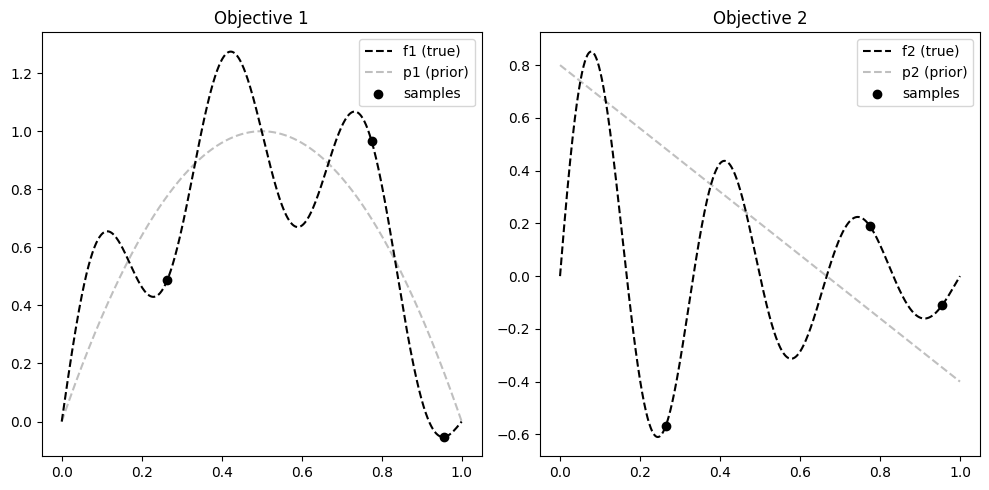

In [147]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(10)
n_initial = 3
initial_indices = rng.choice(len(X), size=n_initial, replace=False)
X_init = X[initial_indices]

Y_init_f1 = f1(X_init)
Y_init_f2 = f2(X_init)

Y_init_p1 = p1(X_init)
Y_init_p2 = p2(X_init)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(X, f1(X), color='black', linestyle='--', alpha=1, label="f1 (true)")
plt.plot(X, p1(X), color='black', linestyle='--', alpha=0.25, label="p1 (prior)")
plt.scatter(X_init, Y_init_f1, c='black', label="samples")
plt.title("Objective 1")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(X, f2(X), color='black', linestyle='--', alpha=1, label="f2 (true)")
plt.plot(X, p2(X), color='black', linestyle='--', alpha=0.25, label="p2 (prior)")
plt.scatter(X_init, Y_init_f2, c='black', label="samples")
plt.title("Objective 2")
plt.legend()

plt.tight_layout()
plt.show()

# Start of bayesian optimization iteration

## Batch size, goal (maximization) and reference point

In [148]:
Batch_size = 3
goal = np.array([[1,1]]) #Maximize both
ref = np.array([[0,0]])

## Argmax function

In [149]:
def top_argmax(array, n = Batch_size):
    """
    Returns the indices of the n largest elements in a NumPy array.

    Args:
    array: The input NumPy array.
    n: number of elements

    Returns:
    A NumPy array containing the indices of the n largest elements.
    """
    flat = array.flatten()
    indices = np.argpartition(flat, -n)[-n:]
    indices = indices[np.argsort(-flat[indices])]
    return indices

## Exclude tested samples

In [150]:
indexExclude_X = []

for x in X_init:
    indexExclude = np.where((x == X).all(1))[0]
    if len(indexExclude) > 0:
        indexExclude_X.append(indexExclude[0])

X_iteration = np.delete(X,indexExclude_X,0)

## Find pareto front and hypervolume

In [151]:
from MOBO.multiobjective import EHVI, Pareto_finder, HV_Calc

y=np.concatenate((Y_init_f1.reshape(-1,1),Y_init_f2.reshape(-1,1)),axis=1)

y_pareto_curr,index=Pareto_finder(y,goal)
hv_curr = (HV_Calc(goal,ref,y_pareto_curr)).reshape(1,1)

## Testing prior values

In [152]:
test_priors = [p1(X_iteration),p2(X_iteration)]

## Lengthscales and optimization loop

In [157]:
from MOBO.gpModel import gp_model
from copy import deepcopy
import multiprocessing
from joblib import Parallel, delayed
import pyDOE

N_GP = 100
ls = pyDOE.lhs(1,N_GP)*0.95 + 0.05

candidates = []
improvements = []
indices = []
Fused_means = []
Fused_sigs = []

for i in range(N_GP):
    N_test = X_iteration.shape[0]

    GP_o1_GT=gp_model(X_init, Y_init_f1.reshape(X_init.shape[0])-Y_init_p1.reshape(X_init.shape[0]), ls[i,:], (np.max(Y_init_f1)*0.625)**2, 0.01*np.ones(X_init.shape[0]), 1, 'SE' , mean=0)
    o1 = [GP_o1_GT]
    
    GP_o2_GT=gp_model(X_init, Y_init_f2.reshape(X_init.shape[0])-Y_init_p2.reshape(X_init.shape[0]), ls[i,:], (np.max(Y_init_f2)*0.625)**2, 0.01*np.ones(X_init.shape[0]), 1, 'SE' , mean=0)
    o2 = [GP_o2_GT]
    
    models = [o1,o2]
    
    fused_means=[]
    fused_vars=[]
    fused_sigs=[]

    for j in range(len(models)):
        y_t,var_t = models[j][0].predict_var(X_iteration)
        fused_means.append(deepcopy(y_t)+test_priors[j].flatten())
        fused_vars.append(deepcopy(var_t))
    
    fused_means=np.transpose(np.array(fused_means))
    fused_vars=np.transpose(np.array(fused_vars))
    fused_sigs=abs(fused_vars)**0.5

    n_jobs=multiprocessing.cpu_count()
    def calc(ii):
        e = EHVI(fused_means[ii].reshape(1,-1),fused_sigs[ii].reshape(1,-1),goal,ref,y_pareto_curr)
        return e

    Ehvi=Parallel(n_jobs)(delayed(calc)(np.array([jj])) for jj in range(N_test))
    Ehvi=np.array(Ehvi)
        
    x_star_indices = top_argmax(Ehvi)
    candidates.append(deepcopy(X_iteration[x_star_indices]))
    improvements.append(deepcopy(Ehvi[x_star_indices]))
    indices.append(x_star_indices)
    Fused_means.append(fused_means)
    Fused_sigs.append(fused_sigs)

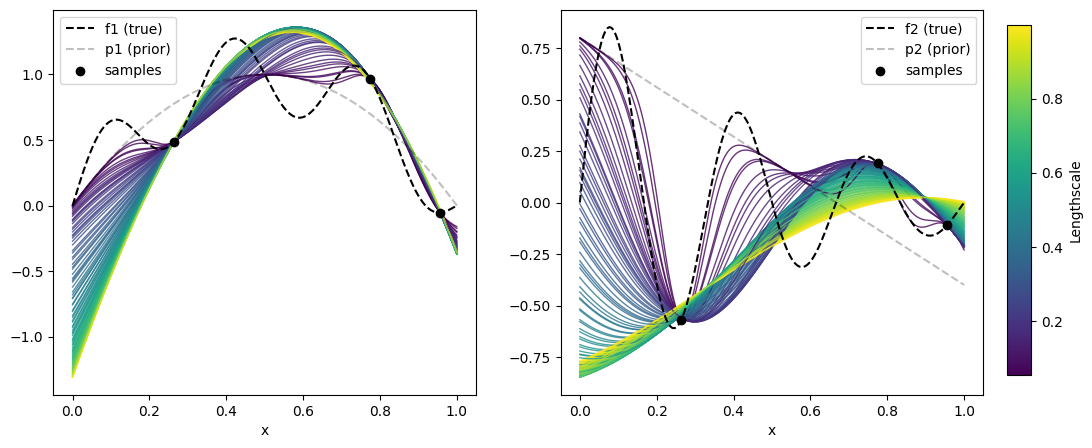

In [207]:
import matplotlib.cm as cm
import matplotlib.colors as colors

norm = colors.Normalize(vmin=min(ls), vmax=max(ls))
cmap = cm.viridis
sm = cm.ScalarMappable(cmap=cmap, norm=norm)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(len(ls)):
    color = cmap(norm(ls[i]))
    plt.plot(X_iteration, Fused_means[i][:,0], color=color, alpha=0.8, lw=1)

plt.plot(X, f1(X), color='black', linestyle='--', label="f1 (true)")
plt.plot(X, p1(X), color='black', linestyle='--', alpha=0.25, label="p1 (prior)")
plt.scatter(X_init, Y_init_f1, c='black', label="samples", zorder=10)
plt.xlabel('x')
plt.legend()

plt.subplot(1, 2, 2)
for i in range(len(ls)):
    color = cmap(norm(ls[i]))
    plt.plot(X_iteration, Fused_means[i][:,1], color=color, alpha=0.8, lw=1)

plt.plot(X, f2(X), color='black', linestyle='--', label="f2 (true)")
plt.plot(X, p2(X), color='black', linestyle='--', alpha=0.25, label="p2 (prior)")
plt.scatter(X_init, Y_init_f2, c='black', label="samples", zorder=10)
plt.xlabel('x')
plt.legend()

cbar_ax = plt.gcf().add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label("Lengthscale")

plt.show()

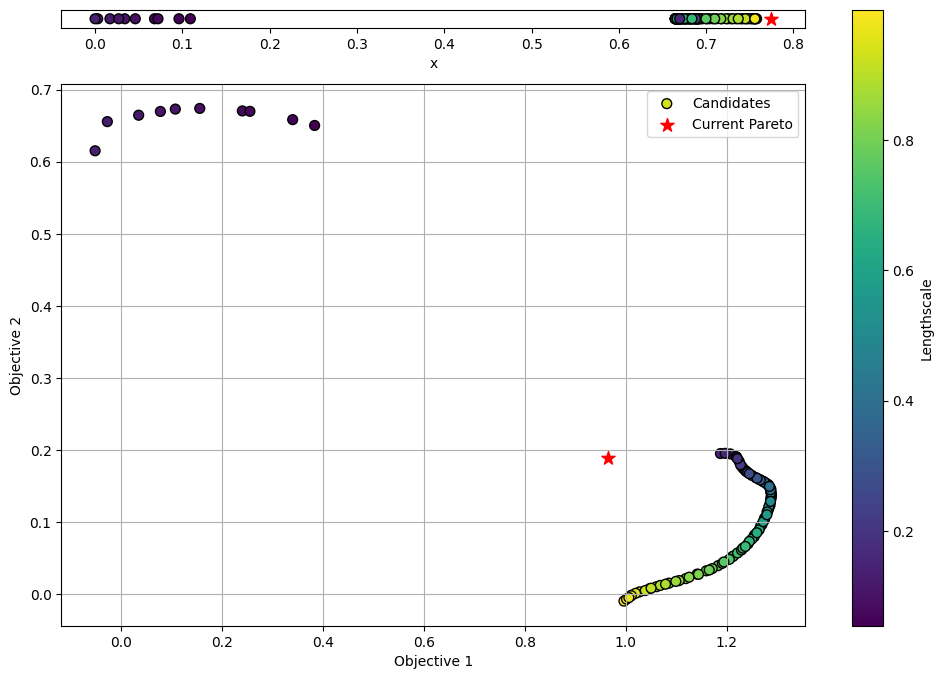

In [208]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 30]})

norm = colors.Normalize(vmin=min(ls), vmax=max(ls))
cmap = cm.viridis

xcand = []
obj1 = []
obj2 = []
for gp in range(N_GP):
    xcand.append(candidates[gp][0,0])
    objs = Fused_means[gp][indices[gp][0],:]
    obj1.append(objs[0])
    obj2.append(objs[1])

X_pareto = X_init[index][:,0]

axs[0].scatter(xcand, np.zeros_like(xcand), c=ls,
               cmap=cmap, norm=norm, s=50, edgecolor='k')
axs[0].scatter(X_pareto, np.zeros_like(X_pareto),
               c='red', s=100, marker='*', label='Current Pareto')
axs[0].set_ylim(-0.2, 0.2)
axs[0].set_xlabel("x")
axs[0].set_yticks([])

sc = axs[1].scatter(obj1, obj2,
                    c=ls, cmap=cmap, norm=norm, s=50, edgecolor='k', label='Candidates')

axs[1].scatter(y_pareto_curr[:, 0], y_pareto_curr[:, 1],
               c='red', s=100, marker='*', label='Current Pareto')
axs[1].set_xlabel("Objective 1")
axs[1].set_ylabel("Objective 2")
axs[1].legend()
axs[1].grid(True)

cbar = fig.colorbar(sc, ax=axs.ravel().tolist())
cbar.set_label("Lengthscale")

plt.show()


# Manual way

In [12]:
import numpy as np

def calcGP(x_test, l):
    # Hyperparameters
    sigma_f2 = 2.0
    sigma_n2 = 0.01
    #l = 1.0  # length scale

    # Training data
    X_train = np.array([[0.0], [0.5]])
    y_train = np.array([1.0, 2.0])
    #X_test = np.array([[1.25]])
    X_test = np.array([[x_test]])

    # RBF kernel function
    def rbf_kernel(x1, x2, sigma_f2, l):
        sqdist = (x1 - x2.T)**2
        return sigma_f2 * np.exp(-0.5 * sqdist / l**2)

    # Compute covariance matrices
    K = rbf_kernel(X_train, X_train, sigma_f2, l) + sigma_n2 * np.eye(len(X_train))
    K_s = rbf_kernel(X_train, X_test, sigma_f2, l)  # shape (2, 1)
    K_ss = rbf_kernel(X_test, X_test, sigma_f2, l)  # shape (1, 1)

    # Invert K
    K_inv = np.linalg.inv(K)

    # Compute posterior mean
    mu_s = K_s.T @ K_inv @ y_train  # shape (1,)

    # Compute posterior variance
    sigma_s2 = K_ss - K_s.T @ K_inv @ K_s  # shape (1,1)
    sigma_s2 = np.clip(sigma_s2, 0, None)  # prevent small negatives due to numerics

    return mu_s[0], np.sqrt(sigma_s2[0,0])

# Print results
#print(f"Posterior mean at x* = {X_test[0,0]:.2f}: {mu_s[0]:.5f}")
#print(f"Posterior variance at x* = {X_test[0,0]:.2f}: {sigma_s2[0,0]:.5f}")

In [13]:
mu, sig = calcGP(1.25,1)

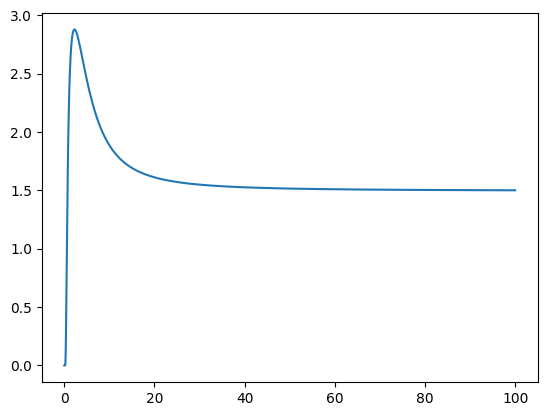

In [23]:
import matplotlib.pyplot as plt
L = np.geomspace(0.001, 100, 1000)
MU = []
for l in L:
    mu, sig = calcGP(1.25,l)
    MU.append(mu)

plt.plot(L,MU)